In [2]:
import pandas as pd
import numpy as np

In [3]:
dl = pd.read_excel("5G_DL.xlsx",sheet_name="Series Formatted Data")
dl = dl.drop(["Technology_Mode","Unnamed: 48"],axis=1)

In [4]:
dl["Time"] = dl["Time"].dt.floor('s')

In [5]:
new_dl = pd.DataFrame()

mean_cols = [
             "NR_UE_RSRP_0",
             "NR_UE_RSRQ_0",
             "NR_UE_SINR_0",	
             "NR_UE_Nbr_RSRP_0",	
             "NR_UE_Nbr_RSRP_1",
             "NR_UE_Nbr_RSRP_2",
             "NR_UE_Nbr_RSRP_3",
             "NR_UE_Nbr_RSRP_4",
             "NR_UE_Nbr_RSRQ_0",
             "NR_UE_Nbr_RSRQ_1",
             "NR_UE_Nbr_RSRQ_2",
             "NR_UE_Nbr_RSRQ_3",
             "NR_UE_Nbr_RSRQ_4"]

last_known_data_cols = [
                        "NR_UE_PCI_0",
                        "NR_UE_Nbr_PCI_0",
                        "NR_UE_Nbr_PCI_1",	
                        "NR_UE_Nbr_PCI_2",	
                        "NR_UE_Nbr_PCI_3",	
                        "NR_UE_Nbr_PCI_4",
                        ]

for row in dl['Time'].unique():

    filtered_row_mean = dl[dl["Time"] == row][mean_cols].mean()
    filtered_row_last = dl[dl["Time"] == row][last_known_data_cols]
    last_known_values = filtered_row_last.apply(lambda x: x.dropna().iloc[-1] if not x.dropna().empty else np.nan)
    filtered_row = pd.concat([pd.Series({'Time': row}), filtered_row_mean, last_known_values])
    new_dl = pd.concat([new_dl, filtered_row.to_frame().T], ignore_index=True)
             
new_dl



,Time,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_RSRP_0,NR_UE_Nbr_RSRP_1,NR_UE_Nbr_RSRP_2,NR_UE_Nbr_RSRP_3,NR_UE_Nbr_RSRP_4,NR_UE_Nbr_RSRQ_0,NR_UE_Nbr_RSRQ_1,NR_UE_Nbr_RSRQ_2,NR_UE_Nbr_RSRQ_3,NR_UE_Nbr_RSRQ_4,NR_UE_PCI_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,NR_UE_Nbr_PCI_2,NR_UE_Nbr_PCI_3,NR_UE_Nbr_PCI_4
0,2025-03-14 12:14:33,-87.1,-11.2,7.3,-97.3,NaN,NaN,NaN,NaN,-16.3,NaN,NaN,NaN,NaN,48.0,76.0,NaN,NaN,NaN,NaN
1,2025-03-14 12:14:34,-85.233333,-11.233333,6.25,-96.266667,NaN,NaN,NaN,NaN,-16.6,NaN,NaN,NaN,NaN,48.0,76.0,NaN,NaN,NaN,NaN
2,2025-03-14 12:14:35,-86.25,-11.1,11.65,-98.25,NaN,NaN,NaN,NaN,-17.05,NaN,NaN,NaN,NaN,48.0,76.0,NaN,NaN,NaN,NaN
3,2025-03-14 12:14:36,-87.6,-10.55,11.6,-99.4,NaN,NaN,NaN,NaN,-16.85,NaN,NaN,NaN,NaN,48.0,76.0,NaN,NaN,NaN,NaN
4,2025-03-14 12:14:37,-86.65,-10.6,11.7,-96.85,NaN,NaN,NaN,NaN,-13.25,NaN,NaN,NaN,NaN,48.0,76.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,2025-03-14 12:32:13,-118.6,-13.2,2.45,-122.85,NaN,NaN,NaN,NaN,-16.95,NaN,NaN,NaN,NaN,68.0,59.0,NaN,NaN,NaN,NaN
1061,2025-03-14 12:32:14,-118.2,-13.55,2.4,-120.85,NaN,NaN,NaN,NaN,-15.6,NaN,NaN,NaN,NaN,68.0,59.0,NaN,NaN,NaN,NaN
1062,2025-03-14 12:32:15,-118.05,-13.25,0.15,-121.2,NaN,NaN,NaN,NaN,-15.75,NaN,NaN,NaN,NaN,68.0,59.0,NaN,NaN,NaN,NaN
1063,2025-03-14 12:32:16,-118.15,-13.1,-1.05,-121.25,NaN,NaN,NaN,NaN,-15.65,NaN,NaN,NaN,NaN,68.0,59.0,NaN,NaN,NaN,NaN


### Osman

In [6]:
for i in dl.columns:
    print(i)
    if dl[i].nunique() > 15 and dl[i].dtype != "object":
        print(dl[i].nunique())
    else:
        print(dl[i].nunique(), ">>>", dl[i].unique())
    print("===")

Message
72480
===
Time
1065
===
Longitude
958
===
Latitude
607
===
NR_UE_PCI_0
11 >>> [ nan  48.  76.  68.   3.  13.  23.  40.  30.  59. 278.  38.]
===
NR_UE_RSRP_0
628
===
NR_UE_RSRQ_0
132
===
NR_UE_SINR_0
493
===
NR_UE_Nbr_PCI_0
11 >>> [ nan  76.  59.  48.  68.   3.  23.  13.  40.  30. 278.  38.]
===
NR_UE_Nbr_PCI_1
10 >>> [ nan  76.  13.  23.  68.  59.  40.  48.  30.  38. 278.]
===
NR_UE_Nbr_PCI_2
7 >>> [ nan  23.  76.  68.  40.  30.  59. 278.]
===
NR_UE_Nbr_PCI_3
3 >>> [nan 76. 68. 59.]
===
NR_UE_Nbr_PCI_4
1 >>> [nan 76.]
===
NR_UE_Nbr_RSRP_0
531
===
NR_UE_Nbr_RSRP_1
282
===
NR_UE_Nbr_RSRP_2
96
===
NR_UE_Nbr_RSRP_3
19
===
NR_UE_Nbr_RSRP_4
2 >>> [   nan -116.8 -123.5]
===
NR_UE_Nbr_RSRQ_0
200
===
NR_UE_Nbr_RSRQ_1
133
===
NR_UE_Nbr_RSRQ_2
59
===
NR_UE_Nbr_RSRQ_3
19
===
NR_UE_Nbr_RSRQ_4
2 >>> [  nan -15.8 -16.9]
===
NR_UE_Timing_Advance
20
===
NR_UE_Pathloss_DL_0
643
===
NR_UE_Throughput_PDCP_DL
1210
===
App_Throughput_DL
910
===
NR_UE_NACK_Rate_DL_0
223
===
NR_UE_Ack_As_Nack_DL_0
54


In [7]:
my_dl = dl.loc[:,"NR_UE_NACK_Rate_UL_0":]

In [8]:
my_dl = my_dl.dropna(axis=1, how='all')

In [9]:
my_dl

,NR_UE_NACK_Rate_UL_0,NR_UE_RACH_Attempt,NR_UE_RACH_OK,NR_UE_RACH_Fail,NR_UE_RACH_Procedure_Count,NR_UE_RRCReEstAttempt,NR_UE_RRCReEstFail,NR_UE_RRCReEst_EndResult,NR_UE_RRCConnectionAttempt,NR_UE_RRCConnectionSetupOk,NR_UE_RRCConnectionComplete,NR_UE_RRCConnectionDrop,NR_UE_RRCHOAttempt,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType
0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
1,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
2,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
3,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
4,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72475,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72476,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72477,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72478,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,0,0,NaN,NaN,NaN


In [10]:
num_cols = []
cat_cols = []
for i in my_dl.columns:
    print(i)
    if dl[i].nunique() > 15 and dl[i].dtype != "object":
        print(dl[i].nunique())
        num_cols.append(i)
    else:
        print(dl[i].nunique(), ">>>", dl[i].unique())
        cat_cols.append(i)
    print("===")

NR_UE_NACK_Rate_UL_0
208
===
NR_UE_RACH_Attempt
2 >>> [0 1]
===
NR_UE_RACH_OK
2 >>> [0 1]
===
NR_UE_RACH_Fail
2 >>> [0 1]
===
NR_UE_RACH_Procedure_Count
41
===
NR_UE_RRCReEstAttempt
2 >>> [0 1]
===
NR_UE_RRCReEstFail
2 >>> [0 1]
===
NR_UE_RRCReEst_EndResult
1 >>> [nan 'Re-establishment failure after Request']
===
NR_UE_RRCConnectionAttempt
2 >>> [0 1]
===
NR_UE_RRCConnectionSetupOk
2 >>> [0 1]
===
NR_UE_RRCConnectionComplete
2 >>> [0 1]
===
NR_UE_RRCConnectionDrop
2 >>> [0 1]
===
NR_UE_RRCHOAttempt
2 >>> [0 1]
===
NR_UE_RRCHOOK
2 >>> [0 1]
===
NR_RRC_MsgType
17 >>> [nan ' UL-DCCH MeasurementReport' ' DL-DCCH RRCReconfiguration'
 ' UL-DCCH RRCReconfigurationComplete' ' BCCH-BCH MIB' ' BCCH-DL_SCH SIB1'
 ' BCCH-DL_SCH SIB2' ' UL-CCCH RRCReestablishmentRequest'
 ' UL-CCCH RRCSetupRequest' ' DL-CCCH RRCSetup'
 ' UL-DCCH RRCSetupComplete' ' DL-DCCH SecurityModeCommand'
 ' UL-DCCH SecurityModeComplete' ' DL-DCCH DLInformationTransfer'
 ' UL-DCCH ULInformationTransfer' ' DL-DCCH RRCRelease'
 

In [11]:
for i in my_dl.columns:
    if my_dl[i].dtype == "object":
        print(my_dl[i].value_counts())
        print("===")

NR_UE_RRCReEst_EndResult
Re-establishment failure after Request    1
Name: count, dtype: int64
===
NR_RRC_MsgType
BCCH-BCH MIB                          76
BCCH-DL_SCH SIB1                      65
UL-DCCH RRCReconfigurationComplete    57
DL-DCCH RRCReconfiguration            57
UL-DCCH MeasurementReport             45
BCCH-DL_SCH SIB2                      10
DL-DCCH DLInformationTransfer          8
DL-CCCH RRCSetup                       6
UL-CCCH RRCSetupRequest                6
UL-DCCH ULInformationTransfer          6
UL-DCCH RRCSetupComplete               6
UL-DCCH SecurityModeComplete           3
DL-DCCH SecurityModeCommand            3
DL-DCCH RRCRelease                     2
UL-CCCH RRCReestablishmentRequest      1
DL-DCCH UECapabilityEnquiry            1
UL-DCCH UECapabilityInformation        1
Name: count, dtype: int64
===
NAS_5GS_MM_MessageType
Registration request            6
Registration accept             3
Registration complete           3
Registration reject             2


In [12]:
num_cols

['NR_UE_NACK_Rate_UL_0', 'NR_UE_RACH_Procedure_Count']

In [13]:
my_dl[num_cols].describe()

,NR_UE_NACK_Rate_UL_0,NR_UE_RACH_Procedure_Count
count,1949.000000,41.000000
mean,5.137814,21.000000
std,8.281015,11.979149
min,0.000000,1.000000
25%,0.000000,11.000000
50%,0.500000,21.000000
75%,9.500000,31.000000
max,100.000000,41.000000


In [14]:
my_dl["Time"] = dl["Time"]

In [15]:
my_dl.groupby("Time").agg({num_cols[0]:["mean"], num_cols[1]:["mean"]}).reset_index()

,Time,NR_UE_NACK_Rate_UL_0,NR_UE_RACH_Procedure_Count
,,mean,mean
0,2025-03-14 12:14:33,NaN,NaN
1,2025-03-14 12:14:34,0.00,NaN
2,2025-03-14 12:14:35,4.20,NaN
3,2025-03-14 12:14:36,0.50,NaN
4,2025-03-14 12:14:37,0.00,NaN
...,...,...,...
1060,2025-03-14 12:32:13,9.30,NaN
1061,2025-03-14 12:32:14,9.50,NaN
1062,2025-03-14 12:32:15,9.05,NaN


In [ ]:
binary_cols = []
for i in cat_cols:
    if my_dl[i].unique().tolist() == [0, 1]:
        binary_cols.append(i)

cat_cols = [i for i in cat_cols if i not in binary_cols]

In [17]:
my_dl[binary_cols]

,NR_UE_RACH_Attempt,NR_UE_RACH_OK,NR_UE_RACH_Fail,NR_UE_RRCReEstAttempt,NR_UE_RRCReEstFail,NR_UE_RRCConnectionAttempt,NR_UE_RRCConnectionSetupOk,NR_UE_RRCConnectionComplete,NR_UE_RRCConnectionDrop,NR_UE_RRCHOAttempt,NR_UE_RRCHOOK
0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
72475,0,0,0,0,0,0,0,0,0,0,0
72476,0,0,0,0,0,0,0,0,0,0,0
72477,0,0,0,0,0,0,0,0,0,0,0
72478,0,0,0,0,0,0,0,0,0,0,0


In [18]:
result = my_dl.groupby("Time").agg({
    col: lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty else np.nan
    for col in cat_cols
}).reset_index()


In [19]:
result

,Time,NR_UE_RRCReEst_EndResult,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType
0,2025-03-14 12:14:33,NaN,NaN,NaN,NaN
1,2025-03-14 12:14:34,NaN,NaN,NaN,NaN
2,2025-03-14 12:14:35,NaN,NaN,NaN,NaN
3,2025-03-14 12:14:36,NaN,NaN,NaN,NaN
4,2025-03-14 12:14:37,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1060,2025-03-14 12:32:13,NaN,NaN,NaN,NaN
1061,2025-03-14 12:32:14,NaN,NaN,NaN,NaN
1062,2025-03-14 12:32:15,NaN,NaN,NaN,NaN
1063,2025-03-14 12:32:16,NaN,NaN,NaN,NaN


In [20]:
dl[["Time", "Longitude", "Latitude"]]

,Time,Longitude,Latitude
0,2025-03-14 12:14:33,NaN,NaN
1,2025-03-14 12:14:33,NaN,NaN
2,2025-03-14 12:14:33,29.02949,41.10723
3,2025-03-14 12:14:33,29.02949,41.10723
4,2025-03-14 12:14:33,29.02949,41.10723
...,...,...,...
72475,2025-03-14 12:32:17,29.02143,41.10031
72476,2025-03-14 12:32:17,29.02143,41.10031
72477,2025-03-14 12:32:17,29.02143,41.10031
72478,2025-03-14 12:32:17,29.02143,41.10031


Text(0.5, 1.0, 'Zamana Göre Coğrafi Dağılım')

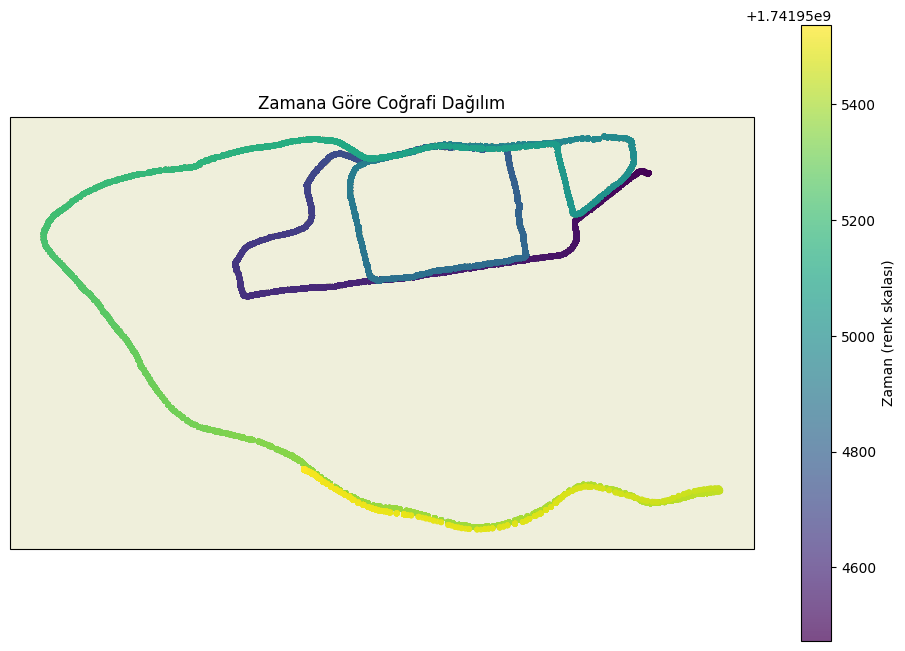

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Zamanı normalize ederek renk skalasına dönüştürün (örneğin Unix zamanı)
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9  # Zamanı sayısal değere çevir

# Harita oluştur
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Scatter plot
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,  # Renk zamanı temsil eder
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.colorbar(sc, label="Zaman (renk skalası)")
ax.set_title("Zamana Göre Coğrafi Dağılım")
# plt.show()

In [22]:
cat_cols

['NR_UE_RRCReEst_EndResult',
 'NR_RRC_MsgType',
 'NAS_5GS_MM_MessageType',
 'NAS_5GS_SM_MessageType']

In [23]:
allpci = mean_cols + last_known_data_cols

In [24]:
allpci

['NR_UE_RSRP_0',
 'NR_UE_RSRQ_0',
 'NR_UE_SINR_0',
 'NR_UE_Nbr_RSRP_0',
 'NR_UE_Nbr_RSRP_1',
 'NR_UE_Nbr_RSRP_2',
 'NR_UE_Nbr_RSRP_3',
 'NR_UE_Nbr_RSRP_4',
 'NR_UE_Nbr_RSRQ_0',
 'NR_UE_Nbr_RSRQ_1',
 'NR_UE_Nbr_RSRQ_2',
 'NR_UE_Nbr_RSRQ_3',
 'NR_UE_Nbr_RSRQ_4',
 'NR_UE_PCI_0',
 'NR_UE_Nbr_PCI_0',
 'NR_UE_Nbr_PCI_1',
 'NR_UE_Nbr_PCI_2',
 'NR_UE_Nbr_PCI_3',
 'NR_UE_Nbr_PCI_4']

In [25]:
pcicols = ["NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_Nbr_PCI_1", 
           "NR_UE_Nbr_PCI_2", "NR_UE_Nbr_PCI_3", "NR_UE_Nbr_PCI_4"]

new_dl = dl[dl[pcicols].isin([278, 38]).any(axis=1)].copy()


In [26]:
new_dl

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCReEst_EndResult,NR_UE_RRCConnectionAttempt,NR_UE_RRCConnectionSetupOk,NR_UE_RRCConnectionComplete,NR_UE_RRCConnectionDrop,NR_UE_RRCHOAttempt,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType
68393,68393,2025-03-14 12:29:58,29.02693,41.09932,278.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
68394,68394,2025-03-14 12:29:58,29.02693,41.09932,68.0,-146.0,-33.2,-16.2,3.0,38.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
68400,68400,2025-03-14 12:29:58,29.02693,41.09932,278.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,BCCH-BCH MIB,NaN,NaN
68417,68417,2025-03-14 12:29:58,29.02699,41.09935,278.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,BCCH-DL_SCH SIB1,NaN,NaN
68418,68418,2025-03-14 12:29:58,29.02699,41.09935,38.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70124,70124,2025-03-14 12:31:25,29.02637,41.09903,38.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
70125,70125,2025-03-14 12:31:25,29.02637,41.09903,38.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,BCCH-BCH MIB,NaN,NaN
70126,70126,2025-03-14 12:31:25,29.02637,41.09903,38.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,BCCH-DL_SCH SIB1,NaN,NaN
70127,70127,2025-03-14 12:31:25,29.02637,41.09903,278.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN


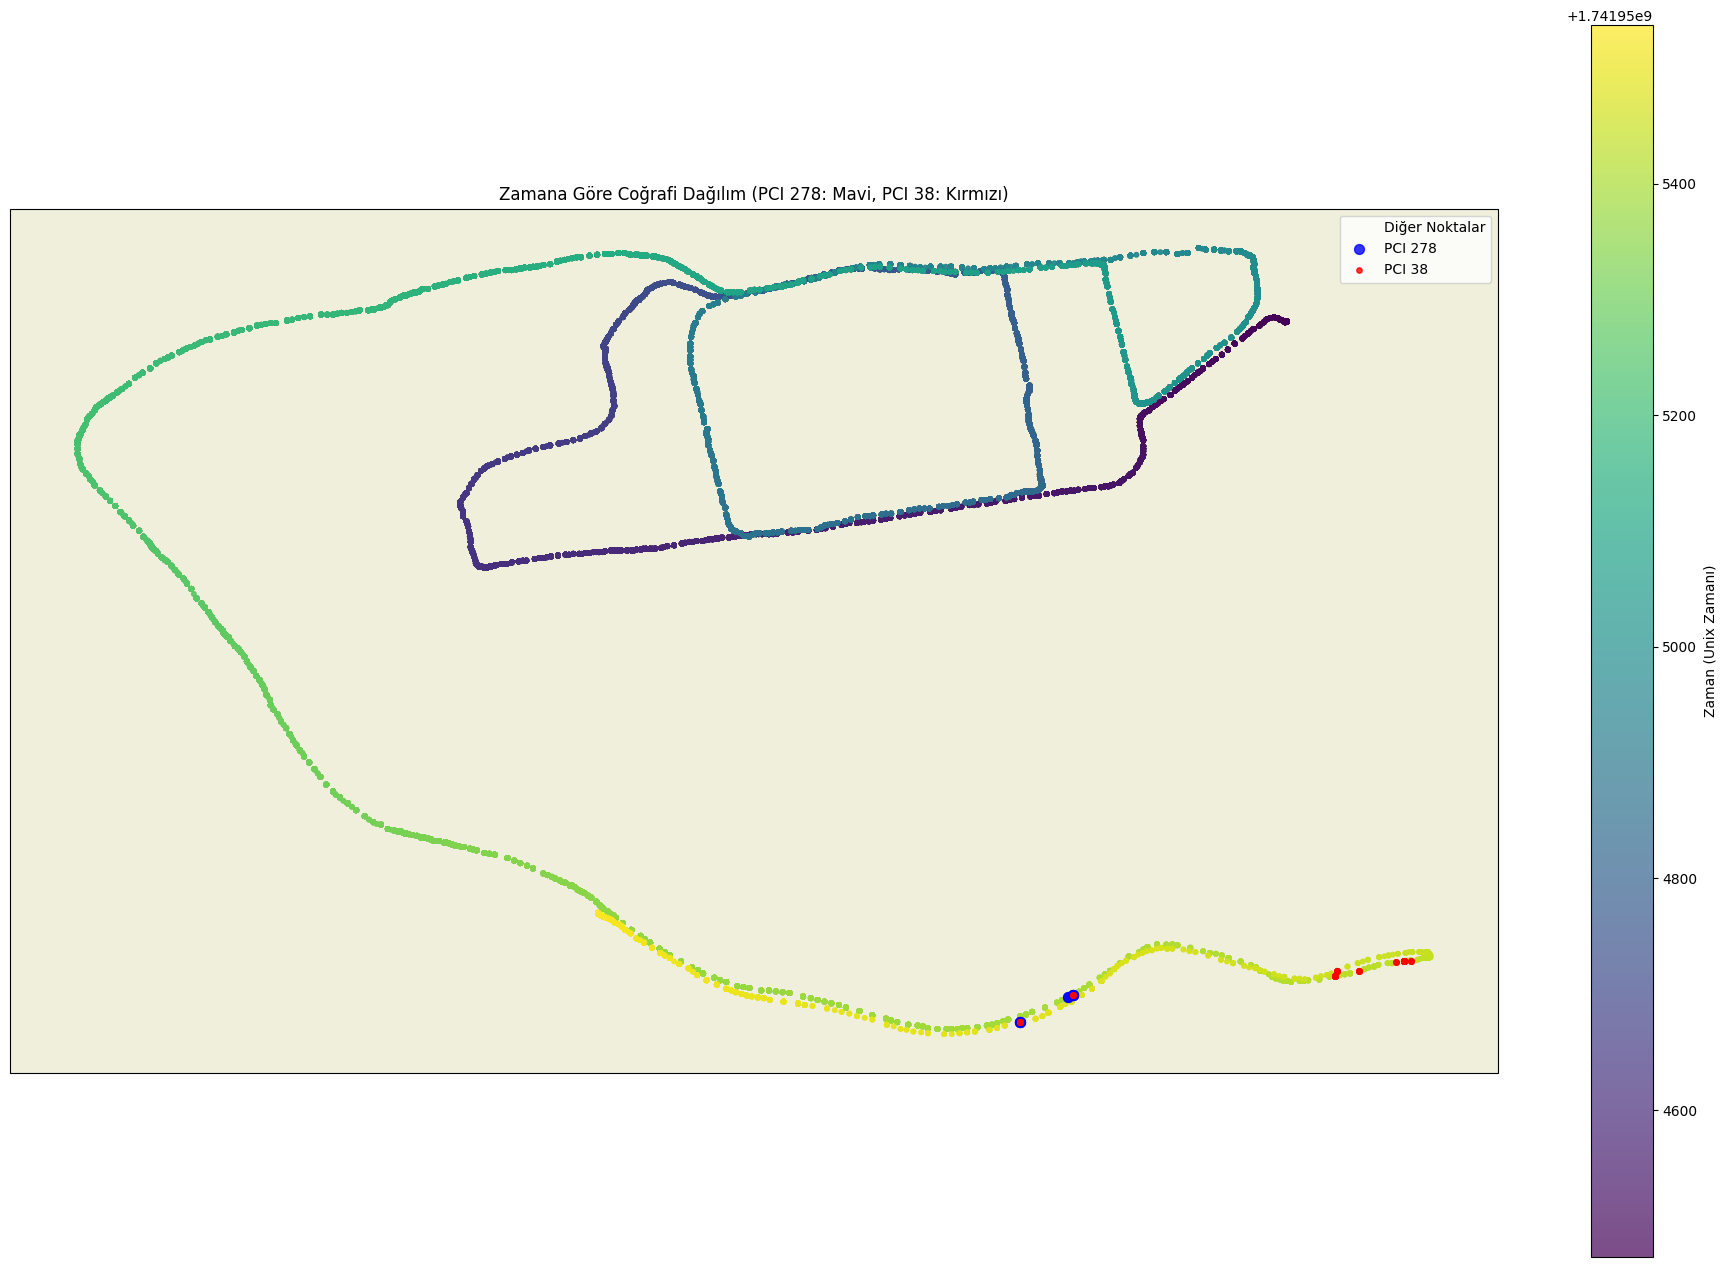

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

# Zamanı normalize ederek renk skalasına dönüştür
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="viridis",
    s=10,
    alpha=0.7,
    label="Diğer Noktalar"
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=50,
    alpha=0.8,
    label="PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=15,
    alpha=0.8,
    label="PCI 38"
)

plt.colorbar(sc, label="Zaman (Unix Zamanı)")
ax.set_title("Zamana Göre Coğrafi Dağılım (PCI 278: Mavi, PCI 38: Kırmızı)")
ax.legend()

plt.show()

In [28]:
base_stations = pd.read_excel("İTÜ 5G Hücre Bilgileri.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'İTÜ 5G Hücre Bilgileri.xlsx'

In [ ]:
base_stations[["PCI ","Longitude","Latitude"]].head(10)

,PCI,Longitude,Latitude
0,30,29.023367,41.107341
1,40,29.022665,41.107087
2,59,29.028122,41.108086
3,48,29.028122,41.108086
4,68,29.027833,41.105469
5,76,29.027833,41.105469
6,3,29.021747,41.104342
7,13,29.021747,41.104342
8,23,29.020503,41.105842


In [ ]:
base_stations

,Kabinet,Sector,Cell Name,Latitude,Longitude,Azimuth [°],Horizontal Beamwidth [°],Vertical Beamwidth [°],Height [m],MIMO,PCI,rachroot,Power [W],Ssbpower [Dbm]
0,WITUFERG,AAS-S1CB,ITUCELL4BG,41.107341,29.023367,50,65,10.0,10,64T64R,30,26,200,17.91
1,WITUFERG,AAS-S2CB,ITUCELL5BG,41.107087,29.022665,260,65,10.0,10,64T64R,40,126,200,17.91
2,WITUFERG,AAS-S3CB,ITUCELL7BG,41.108086,29.028122,230,65,10.0,6,64T64R,59,42,200,17.91
3,WITUFESG,AAS-S1CB,ITUCELL6BG,41.108086,29.028122,110,65,10.0,6,64T64R,48,69,200,17.91
4,WITUFESG,AAS-S2CB,ITUCELL8BG,41.105469,29.027833,255,65,9.5,18,32T32R,68,132,200,17.91
5,WITUFESG,AAS-S3CB,ITUCELL9BG,41.105469,29.027833,340,65,9.5,18,32T32R,76,75,200,17.91
6,WITUPAG,AAS-S1CB,ITUCELL1BG,41.104342,29.021747,300,65,10.0,6,64T64R,3,30,200,17.91
7,WITUPAG,AAS-S2CB,ITUCELL2BG,41.104342,29.021747,40,65,10.0,6,64T64R,13,130,200,17.91
8,WITUPAG,AAS-S3CB,ITUCELL3BG,41.105842,29.020503,130,65,10.0,6,64T64R,23,93,200,17.91


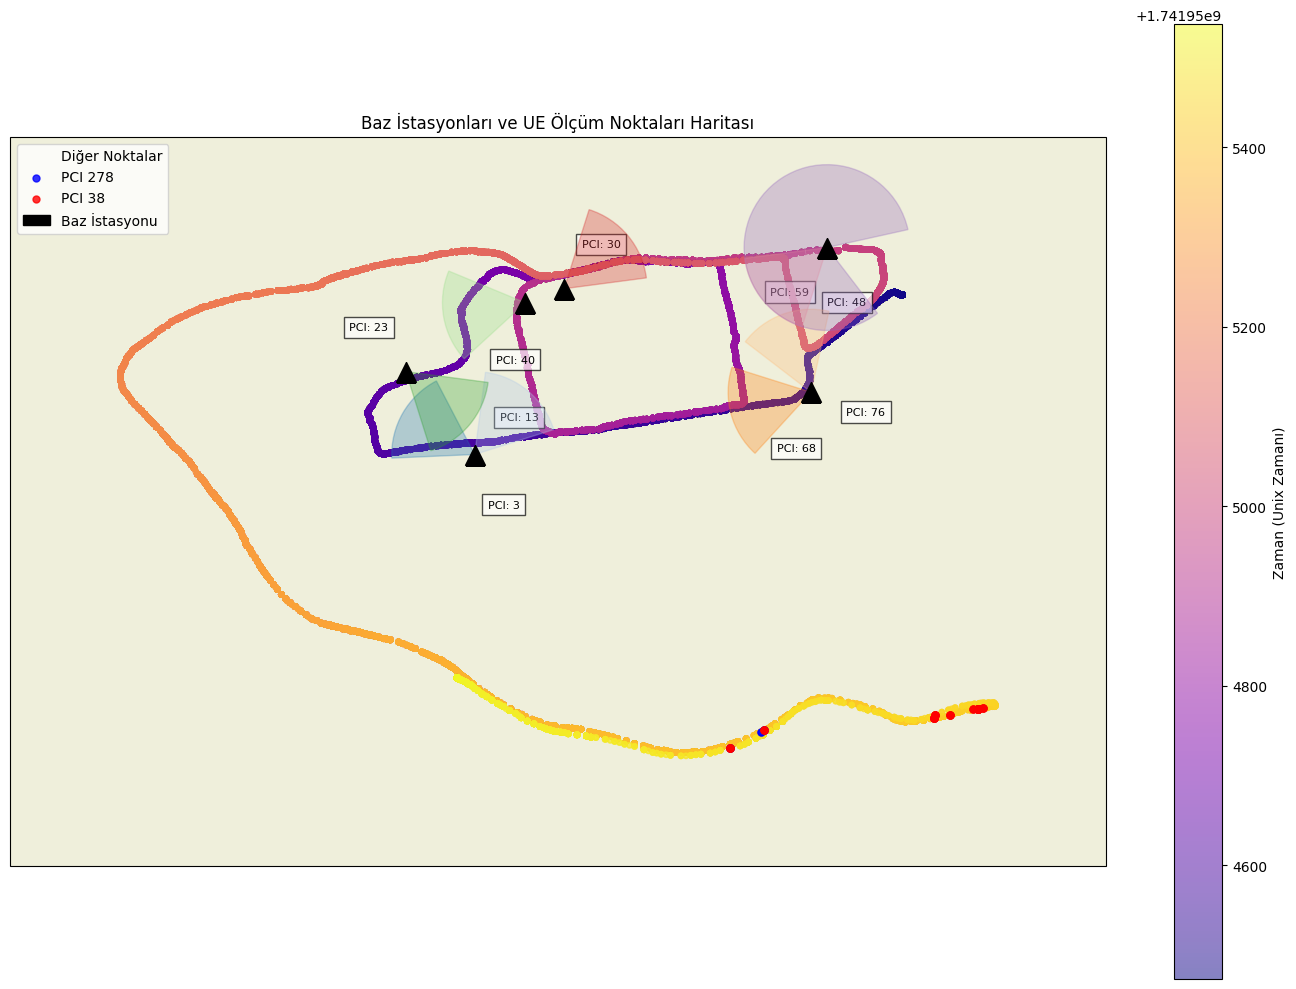

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
import io
import matplotlib.colors as mcolors
from matplotlib.patches import Wedge


bs_df = pd.read_csv("base_stations.csv", sep=",")

# Zamanı normalize ederek renk skalasına dönüştür
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Haritayı ölçeklendir ve baz istasyonları etrafına odakla
buffer = 0.002  # Yaklaşık 200 metre buffer
min_lon = min(bs_df["Longitude"].min(), dl["Longitude"].min()) - buffer
max_lon = max(bs_df["Longitude"].max(), dl["Longitude"].max()) + buffer
min_lat = min(bs_df["Latitude"].min(), dl["Latitude"].min()) - buffer
max_lat = max(bs_df["Latitude"].max(), dl["Latitude"].max()) + buffer

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=15,
    alpha=0.5,
    label="Diğer Noktalar"
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=25,
    alpha=0.8,
    label="PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=25,
    alpha=0.8,
    label="PCI 38"
)

# PCI renk haritası oluştur - baz istasyonlarını temsil etmek için
pci_cmap = plt.cm.tab20(np.linspace(0, 1, 20))
pci_colors = dict()

# Baz istasyonlarını ekle
station_groups = bs_df.groupby(["Latitude", "Longitude"])
for (lat, lon), group in station_groups:
    # Baz istasyonu konumunu işaretle
    ax.plot(lon, lat, 'k^', markersize=14, markeredgecolor='black', zorder=10)
    
    # Her sektör için kapsama alanını çiz
    for _, row in group.iterrows():
        azimuth = row["Azimuth [°]"]
        beamwidth = row["Horizontal Beamwidth [°]"]
        pci = row["PCI "]
        
        # Her PCI için tutarlı renk ataması yap
        if pci not in pci_colors:
            pci_colors[pci] = pci_cmap[len(pci_colors) % 20]
        
        # Kapsama alanını dilim (wedge) olarak göster
        # Azimuth açısı, beamwidth ve kapsama mesafesi
        start_angle = (azimuth - beamwidth/2) % 360
        end_angle = (azimuth + beamwidth/2) % 360
        
        # Açıları matematik açısından (saat yönünün tersi) coğrafi açıya (kuzeyden saat yönünde) dönüştür
        start_angle = (90 - start_angle) % 360
        end_angle = (90 - end_angle) % 360
        if start_angle > end_angle:
            start_angle, end_angle = end_angle, start_angle
            
        # Kapsama mesafesi - güç ve yükseklik baz alınarak basit bir tahmin
        # Gerçek kapsama alanı için daha karmaşık propagasyon modelleri kullanılmalıdır
        coverage_radius = 0.0015  # Yaklaşık 150 metre
        
        wedge = Wedge((lon, lat), coverage_radius, start_angle, end_angle, 
                     alpha=0.3, color=pci_colors[pci], zorder=5)
        ax.add_patch(wedge)
        
        # PCI değerini göster
        # Yön vektörünün ortasında PCI değerini göster
        middle_angle_rad = np.radians((start_angle + end_angle) / 2)
        # Kartezyen koordinatlara dönüştür (matematik açısı olduğundan sin ve cos yer değiştirir)
        dx = np.sin(middle_angle_rad) * coverage_radius * 0.7
        dy = np.cos(middle_angle_rad) * coverage_radius * 0.7
        ax.text(lon + dx, lat + dy, f"PCI: {int(pci)}", fontsize=8, 
                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))

# Renk ölçeği ekle
cbar = plt.colorbar(sc, label="Zaman (Unix Zamanı)")

ax.set_title("Baz İstasyonları ve UE Ölçüm Noktaları Haritası")

# Lejant oluştur
handles, labels = ax.get_legend_handles_labels()

# Baz istasyonu için lejant ekle
station_marker = mpatches.Patch(color='black', label='Baz İstasyonu')
handles.append(station_marker)
labels.append('Baz İstasyonu')

ax.legend(handles=handles, labels=labels, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
dl[dl["NR_UE_PCI_0"].notna()]

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCReEst_EndResult,NR_UE_RRCConnectionAttempt,NR_UE_RRCConnectionSetupOk,NR_UE_RRCConnectionComplete,NR_UE_RRCConnectionDrop,NR_UE_RRCHOAttempt,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType
1,1,2025-03-14 12:14:33,NaN,NaN,48.0,-87.1,-11.2,7.3,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
27,27,2025-03-14 12:14:34,29.02949,41.10723,48.0,-84.4,-11.0,6.9,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
82,82,2025-03-14 12:14:34,29.02949,41.10723,48.0,-85.1,-11.2,NaN,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
92,92,2025-03-14 12:14:34,29.02949,41.10723,48.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
111,111,2025-03-14 12:14:34,29.02949,41.10723,48.0,-86.2,-11.5,5.6,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72328,72328,2025-03-14 12:32:15,29.02143,41.10030,68.0,-118.3,-13.4,0.0,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72359,72359,2025-03-14 12:32:16,29.02143,41.10030,68.0,-117.9,-13.1,-0.7,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72386,72386,2025-03-14 12:32:16,29.02143,41.10030,68.0,-118.4,-13.1,-1.4,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72418,72418,2025-03-14 12:32:17,29.02143,41.10031,68.0,-118.9,-13.3,-1.5,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
